In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from unsflow.greitzer.greitzer import Greitzer, unstalled_characteristic
import matplotlib.cm as cm
import os
from unsflow.utils.thesis_plots import *

In [60]:
listDir = os.listdir('../')
listDir = [x for x in listDir if x.split('_')[0] == 'KT']
ktValues = [float(x.split('_')[1]) for x in listDir]

# sort both lists based on ktValues
sorted_pairs = sorted(zip(ktValues, listDir))  # sorts by first element of tuple, i.e., kt
ktValues, listDir = zip(*sorted_pairs)

# convert back to lists if needed
ktValues_sorted = list(ktValues)
listDir_sorted = list(listDir)

In [61]:
results = []
for dir in listDir:
    file = '../' + dir + '/results/results.pkl'
    with open(file, 'rb') as f:
        results.append(pickle.load(f))
    

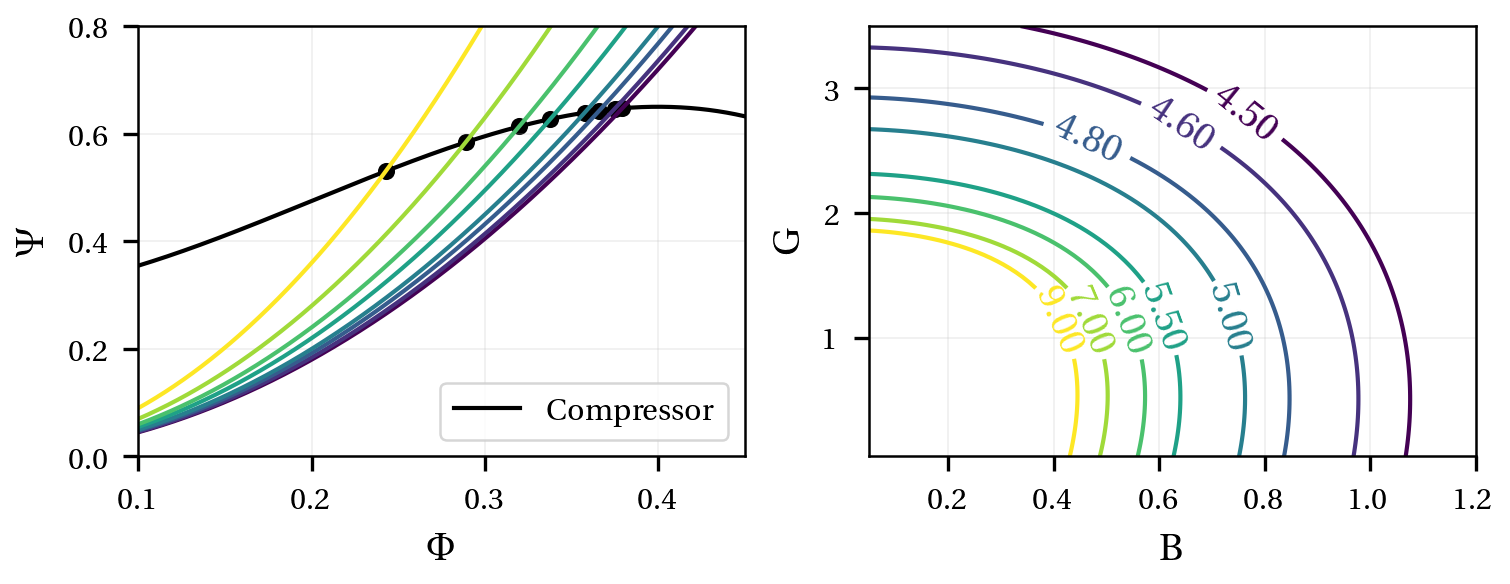

In [65]:
set_thesis_style()
fig, ax = create_figure(fraction=1.0, aspect_ratio=1.3, subplots=(1, 2))

ktValues = np.array(ktValues)  # make sure ktValues is a numpy array
cmap = cm.viridis
colors = np.linspace(0, 1, len(ktValues))
contour_sets = []

for i in range(len(results)):
    color = cmap(colors[i])
    
    W_param = results[i].W_param
    H_param = results[i].H_param
    psi_c_0_param = results[i].psi_c_0_param
    phi = np.linspace(0,1,10000)
    psi_c = unstalled_characteristic(phi, H_param, W_param, psi_c_0_param)
    psi_v = phi**2 * ktValues[i]
    
    if i==0:
        ax[0].plot(phi, psi_c, '-k', label='Compressor')
    
    color = cmap(colors[i])
    ax[0].plot(phi, psi_v, c = color, ls='-')
    idx_intersection = np.argmin(np.abs(psi_c-psi_v))
    ax[0].scatter(phi[idx_intersection], psi_c[idx_intersection], c='k')
    
    
    cs = ax[1].contour(
        results[i].B_grid,
        results[i].G_grid,
        results[i].stabilityMap,
        levels=[0],
        colors=[color],
        linestyles='-',
    )
    if results[i].stabilityMap.max() > 0:
        fmt = {0: f"{ktValues[i]:.2f}"}  # 0 is the level of the contour
        ax[1].clabel(cs, fmt=fmt, inline=True)
    
    contour_sets.append(cs)

# Create a ScalarMappable for the colorbar
sm = cm.ScalarMappable(cmap=cmap)
sm.set_array([])  # dummy array for colorbar
# cbar = fig.colorbar(sm, ax=ax)  # pass the Axes explicitly
# cbar.set_label(r'$k_{\rm t}$')
plt.grid(alpha=0.2)
plt.xlim(right=1.2)
# plt.ylim(top=3.5)
ax[1].set_xlabel('B')
ax[1].set_ylabel('G')


ax[0].set_xlim([0.1, 0.45])
ax[0].set_ylim([0, 0.8])
ax[0].grid(alpha=0.2)
ax[0].set_xlabel(r'$\Phi$')
ax[0].set_ylabel(r'$\Psi$')
ax[0].legend()
fig.savefig('compressor_map_variable_points.pdf')    